# ME 3300 Lab 02 — Solution Notebook
**Sensor Calibration and Dynamic Measurement of a Pendulum**

Instructor solution. Runs against the synthetic TA dataset in `../Data/`
(generated by `generate_synthetic_data.py`); with student data, only
`skiprows` and the tuned model parameters should need attention.

Structure follows the lab manual: Part 4 (calibration), Part 5 (free swing),
Part 6 (model overlay).

## Part 4 — Calibration

Load all 11 calibration recordings, average each, fit the calibration
equation $\theta = a_1 V + a_0$, and quantify fit quality
(norm of residuals, $s_{yx}$, 95% CI, $S_{a_1}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10

# The known calibration angles
angles_deg = np.array([-90, -70, -50, -30, -10, 0, 10, 30, 50, 70, 90])

data_dir = '../Data/'
mean_voltages = np.zeros(len(angles_deg))

for i, angle in enumerate(angles_deg):
    sign = 'n' if angle < 0 else 'p'
    filename = f'{data_dir}Ang_{sign}{abs(angle)}Deg.csv'
    df = pd.read_csv(filename, skiprows=6)   # 6 metadata lines in WaveForms export
    mean_voltages[i] = df.iloc[:, 1].mean()

print(np.round(mean_voltages, 4))

[0.6581 0.8766 1.0888 1.3151 1.5145 1.6495 1.7613 1.9816 2.2275 2.4391
 2.646 ]


In [2]:
# --- Fit: angle = a1 * voltage + a0 ---
coeffs     = np.polyfit(mean_voltages, angles_deg, 1)   # [a1, a0]
angles_fit = np.polyval(coeffs, mean_voltages)

# --- Fit quality ---
N      = len(angles_deg)
nu     = N - 2
resid  = angles_deg - angles_fit
norm_r = np.sqrt(np.sum(resid**2))          # norm of residuals ||r||
s_yx   = norm_r / np.sqrt(nu)               # standard error of fit
t_val  = stats.t.ppf(0.975, df=nu)          # two-sided 95% -> 0.975
CI     = t_val * s_yx
S_a1   = s_yx / np.sqrt(np.sum((mean_voltages - np.mean(mean_voltages))**2))

print(f"Calibration: theta = {coeffs[0]:.4f} V {coeffs[1]:+.4f}")
print(f"norm of residuals = {norm_r:.4f} deg")
print(f"s_yx  = {s_yx:.4f} deg   (t_{nu},95% = {t_val:.3f}, CI = +/-{CI:.4f} deg)")
print(f"S_a1  = {S_a1:.4f} deg/V")

np.savetxt('../Data/calibration_coeffs.csv', coeffs,
           header='a1 (deg/V), a0 (deg)', delimiter=',')

Calibration: theta = 89.7251 V -148.1115
norm of residuals = 3.2379 deg
s_yx  = 1.0793 deg   (t_9,95% = 2.262, CI = +/-2.4416 deg)
S_a1  = 0.5332 deg/V


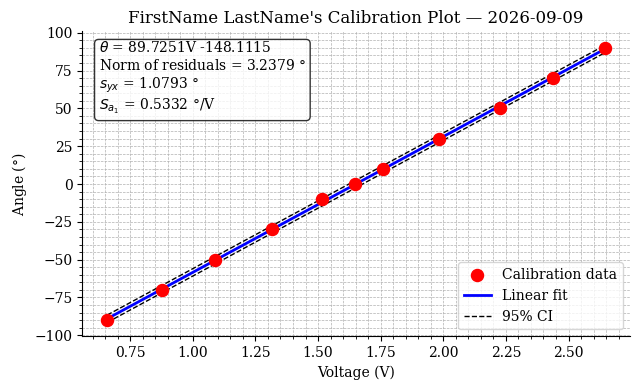

In [3]:
# --- Calibration plot ---
v_range = np.linspace(mean_voltages.min(), mean_voltages.max(), 200)

fig, ax = plt.subplots(figsize=(6.5, 4.0))
fig.patch.set_facecolor('white')
ax.scatter(mean_voltages, angles_deg, s=75, color='red', zorder=5,
           label='Calibration data')
ax.plot(v_range, np.polyval(coeffs, v_range), color='blue', linewidth=2,
        label='Linear fit')
ax.plot(v_range, np.polyval(coeffs, v_range) + CI, 'k--', linewidth=1,
        label='95% CI')
ax.plot(v_range, np.polyval(coeffs, v_range) - CI, 'k--', linewidth=1)

cal_text = (f'$\\theta$ = {coeffs[0]:.4f}V {coeffs[1]:+.4f}\n'
            f'Norm of residuals = {norm_r:.4f} $\\degree$\n'
            f'$s_{{yx}}$ = {s_yx:.4f} $\\degree$\n'
            f'$S_{{a_1}}$ = {S_a1:.4f} $\\degree$/V')
ax.text(0.03, 0.97, cal_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Angle ($\\degree$)')
ax.set_title("FirstName LastName's Calibration Plot — 2026-09-09")
ax.legend(loc='lower right')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.minorticks_on()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig('../Figures/FirstName_LastName_Lab02_Calibration.pdf', dpi=600,
            bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab02_Calibration.png', dpi=600,
            bbox_inches='tight')
plt.show()

## Part 5 — Free Swing

Load the swing recording, apply the calibration, trim to the release moment,
and measure $T_d$ and $\omega_d$.

In [4]:
swing    = pd.read_csv('../Data/FirstName_LastName_Lab02_Swing.csv', skiprows=6)
time_raw = swing.iloc[:, 0].values
volt_raw = swing.iloc[:, 1].values

# Volts -> degrees via the calibration
angle_raw = np.polyval(coeffs, volt_raw)

# Trim so t = 0 is the release
dv    = np.abs(np.diff(volt_raw))
idx0  = np.argmax(dv > 0.01)
time  = time_raw[idx0:] - time_raw[idx0]
angle = angle_raw[idx0:]

print(f"Release detected at t = {time_raw[idx0]:.3f} s (sample {idx0})")

Release detected at t = 1.650 s (sample 165)


In [5]:
# --- Measure Td from zero crossings (average over many periods) ---
sgn = np.sign(angle - np.mean(angle))
zc  = np.where(np.diff(sgn) != 0)[0]          # indices of zero crossings
Td  = 2 * np.mean(np.diff(time[zc[:20]]))     # 2 crossings per period
wd  = 2 * np.pi / Td
print(f"T_d = {Td:.4f} s,  omega_d = {wd:.4f} rad/s")

T_d = 1.1126 s,  omega_d = 5.6471 rad/s


## Part 6 — Simulate the Model and Overlay

Simple pendulum model
$\ddot\theta + 2\zeta\omega_n\dot\theta + \omega_n^2\sin\theta = 0$
rewritten as two first-order ODEs and integrated with `solve_ivp`.

**Tuned values for the synthetic dataset** (student values will differ):
`L = 0.290 m`, `zeta = 0.028`, `theta0 = 88 deg`.

In [6]:
from scipy.integrate import solve_ivp

# --- Tuned model parameters ---
L    = 0.290                 # m (tuned; ruler value ~0.29 m)
g    = 9.81
omega_n = np.sqrt(g / L)
zeta = 0.028                 # tuned
theta0 = np.radians(88.0)    # actual release was slightly below horizontal
omega0 = 0.0

def pendulum_ode(t, y):
    theta, omega = y
    return [omega, -2*zeta*omega_n*omega - omega_n**2*np.sin(theta)]

t_eval = np.linspace(time[0], time[-1], 3000)
sol = solve_ivp(pendulum_ode, (time[0], time[-1]), [theta0, omega0],
                t_eval=t_eval, max_step=0.005)
theta_model_deg = np.degrees(sol.y[0])

# Model period for comparison
print(f"Model omega_n = {omega_n:.4f} rad/s (small-angle Td = {2*np.pi/omega_n:.4f} s)")

Model omega_n = 5.8161 rad/s (small-angle Td = 1.0803 s)


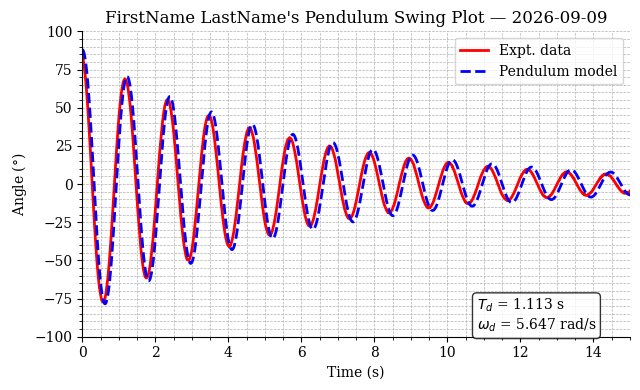

In [7]:
# --- Swing plot with model overlay ---
fig2, ax2 = plt.subplots(figsize=(6.5, 4.0))
fig2.patch.set_facecolor('white')
ax2.plot(time, angle, color='red', linewidth=2, label='Expt. data')
ax2.plot(sol.t, theta_model_deg, color='blue', linewidth=2, linestyle='--',
         label='Pendulum model')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Angle ($\\degree$)')
ax2.set_title("FirstName LastName's Pendulum Swing Plot — 2026-09-09")
ax2.set_xlim(0, 15)
ax2.set_ylim(-100, 100)
ax2.legend(loc='upper right')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.minorticks_on()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.text(0.72, 0.13, f'$T_d$ = {Td:.3f} s\n$\\omega_d$ = {wd:.3f} rad/s',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
fig2.savefig('../Figures/FirstName_LastName_Lab02_Swing.pdf', dpi=600,
             bbox_inches='tight')
fig2.savefig('../Figures/FirstName_LastName_Lab02_Swing.png', dpi=600,
             bbox_inches='tight')
plt.show()

## Grading / checking notes (TA)

- **Calibration slope** should be ~+90 deg/V with a 3.3 V supply if wired as in
  the manual (angle increasing with voltage). A negative slope just means the
  student wired V+/GND to opposite pot ends — the calibration is still valid.
- **`skiprows`** must match the student's export; wrong values usually produce
  NaNs or a shifted first data point.
- **`t.ppf(0.975, ...)`** — passing 0.95 is the most common error; it shrinks
  the CI (t = 1.833 vs 2.262 for nu = 9).
- **Td** should be ~1.0–1.2 s for our pendulums; wd ~ 5–6 rad/s.
- Model overlay: expect close agreement for the first several cycles and
  growing phase drift later — that's physical (amplitude-dependent period,
  non-viscous friction), not an error.